In [1]:
import glob
import os
import tmd
import pandas
import numpy as np
import matplotlib.pyplot as plt
from morph_tool import morphdb
import neurom as nm
from tmd import view
import seaborn as sns

In [4]:
dfH = morphdb.MorphDB.from_neurondb('MorphologyData/Human/zero_diameter_release/h5/neurondb.xml').df


In [5]:
dfR = morphdb.MorphDB.from_neurondb('MorphologyData/Rat/04_ZeroDiameterFix-h5/neuronDB.xml').df


In [6]:
Hl23_df = dfH.loc[dfH['mtype'].isin(['L2_PC', 'L2_STPC', 'L2_PTPC', 'L3_PC', 'L3_STPC', 'L3_PTPC'])]
Rl23_df = dfR.loc[dfR['mtype'].isin(['L2_IPC', 'L2_TPC:A', 'L2_TPC:B', 'L3_TPC:A', 'L3_TPC:C'])]

print('Human L23 PC:', len(Hl23_df), ' \nRat L23 PC:', len(Rl23_df))

Human L23 PC: 366  
Rat L23 PC: 103


In [7]:
Hl4_df = dfH.loc[dfH['use_axon'] == True].loc[dfH['mtype'].isin(['L4_PC', 'L45_PC'])]
Rl4_df = dfR.loc[dfR['use_axon'] == True].loc[dfR['mtype'].isin(['L4_UPC', 'L4_TPC'])]

print('Human L4 PC:', len(Hl4_df), ' \nRat L4 PC:', len(Rl4_df))

Human L4 PC: 16  
Rat L4 PC: 48


In [8]:
Hl56_df = dfH.loc[dfH['use_axon'] == True].loc[dfH['mtype'].isin(['L5_PC', 'L56_PC', 'L6_PC'])]
Rl56_df = dfR.loc[dfR['use_axon'] == True].loc[dfR['mtype'].isin(['L5_UPC', 'L5_TPC:A', 'L5_TPC:B', 'L5_TPC:C', 'L6_UPC', 'L6_TPC:A', 'L6_TPC:B', 'L6_TPC:C', 'L6_BPC', 'L6_IPC', 'L6_HPC'])]

print('Human L5 PC:', len(Hl56_df), ' \nRat L5 PC:', len(Rl56_df))

Human L5 PC: 29  
Rat L5 PC: 181


In [9]:
Hl_IN_df = dfH.loc[dfH['use_axon'] == True].loc[dfH['mtype'].isin(['BC', 'IN'])]
Rl_IN_df = dfR.loc[dfR['use_axon'] == True].loc[dfR['mtype'].isin([
       'L1_DAC', 'L1_HAC', 'L1_LAC', 'L1_NGC-DA', 'L1_NGC-SA', 'L1_SAC',
       'L23_BP', 'L23_BTC', 'L23_CHC', 'L23_DBC', 'L23_LBC', 'L23_MC','L23_NBC', 'L23_NGC', 'L23_SBC',
       'L4_BP', 'L4_BTC', 'L4_CHC', 'L4_DBC','L4_LBC', 'L4_MC', 'L4_NBC', 'L4_NGC', 'L4_SBC', 
       'L5_BP', 'L5_BTC', 'L5_CHC', 'L5_DBC','L5_LBC', 'L5_MC', 'L5_NBC', 'L5_SBC',
       'L6_BTC', 'L6_CHC', 'L6_DBC','L6_LBC', 'L6_MC', 'L6_NBC', 'L6_NGC','L6_SBC'])]

print('Human L6 PC:', len(Hl_IN_df), ' \nRat L6 PC:', len(Rl_IN_df))

Human L6 PC: 48  
Rat L6 PC: 661


In [10]:
popH_nm = {'l23': nm.load_morphologies([l for l in Hl23_df['path'].tolist() if l is not None ]),
           'l4': nm.load_morphologies(Hl4_df['path'].tolist()),
           'l56': nm.load_morphologies(Hl56_df['path'].tolist()),
           'lin': nm.load_morphologies(Hl_IN_df['path'].tolist())}

In [11]:
popR_nm = {'l23': nm.load_morphologies([l for l in Rl23_df['path'].tolist() if l is not None ]),
           'l4': nm.load_morphologies(Rl4_df['path'].tolist()),
           'l56': nm.load_morphologies(Rl56_df['path'].tolist()),
           'lin': nm.load_morphologies(Rl_IN_df['path'].tolist())}

In [12]:
sec_lenH = {i: [nm.get('total_length', n, neurite_type=nm.APICAL_DENDRITE) + nm.get('total_length', n, neurite_type=nm.BASAL_DENDRITE) for n in popH_nm[i].morphologies] for i in popH_nm}

In [13]:
sec_lenR = {i: [nm.get('total_length', n, neurite_type=nm.APICAL_DENDRITE) + nm.get('total_length', n, neurite_type=nm.BASAL_DENDRITE) for n in popR_nm[i].morphologies] for i in popR_nm}

In [14]:
sec_lenR_axon = {i: [nm.get('total_length', n, neurite_type=nm.AXON) for n in popR_nm[i].morphologies] for i in popR_nm}

In [15]:
sec_lenH_axon = {i: [nm.get('total_length', n, neurite_type=nm.AXON) for n in popH_nm[i].morphologies] for i in popH_nm}

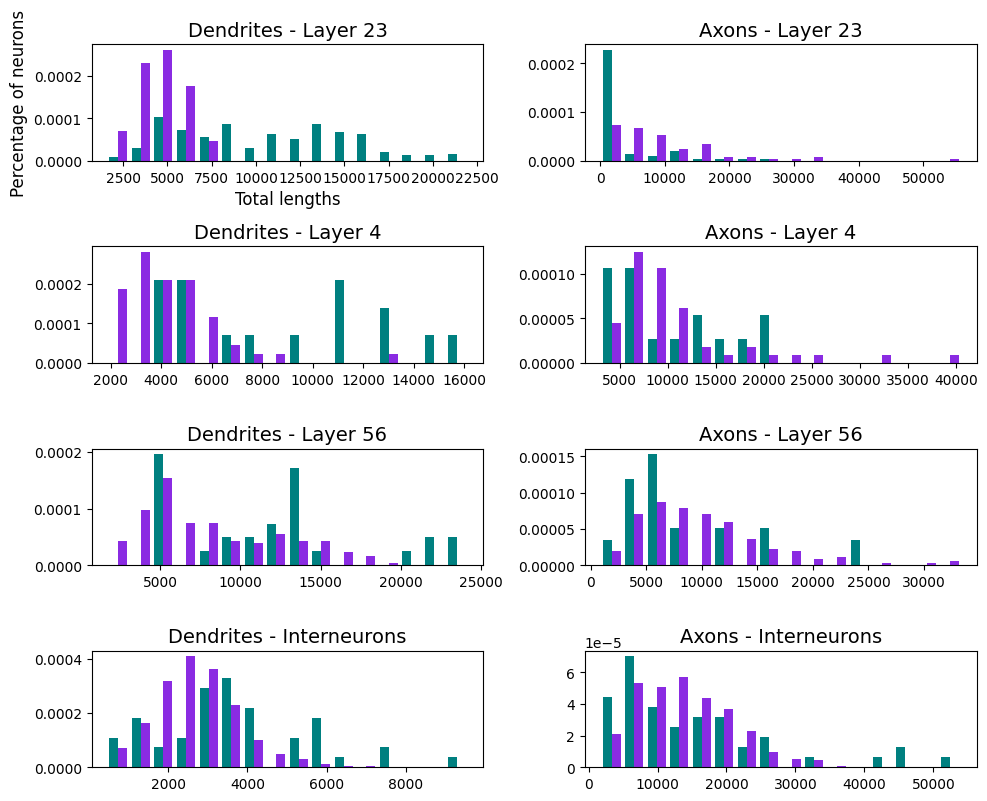

In [16]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(421)
_ = ax.hist([sec_lenH['l23'], sec_lenR['l23']], color=['teal', 'blueviolet'], density=True, bins=16)
ax.set_title("Dendrites - Layer 23", fontsize=14)
ax.set_xlabel("Total lengths", fontsize=12)
ax.set_ylabel("Percentage of neurons", fontsize=12)

ax = fig.add_subplot(422)
_ = ax.hist([sec_lenH_axon['l23'], sec_lenR_axon['l23']], color=['teal', 'blueviolet'], density=True, bins=16)
ax.set_title("Axons - Layer 23", fontsize=14)

ax = fig.add_subplot(423)
_ = ax.hist([sec_lenH['l4'], sec_lenR['l4']], color=['teal', 'blueviolet'], density=True, bins=16)
ax.set_title("Dendrites - Layer 4", fontsize=14)
ax = fig.add_subplot(424)
_ = ax.hist([sec_lenH_axon['l4'], sec_lenR_axon['l4']], color=['teal', 'blueviolet'], density=True, bins=16)
ax.set_title("Axons - Layer 4", fontsize=14)


ax = fig.add_subplot(425)
_ = ax.hist([sec_lenH['l56'], sec_lenR['l56']], color=['teal', 'blueviolet'], density=True, bins=16)
ax.set_title("Dendrites - Layer 56", fontsize=14)
ax = fig.add_subplot(426)
_ = ax.hist([sec_lenH_axon['l56'], sec_lenR_axon['l56']], color=['teal', 'blueviolet'], density=True, bins=16)
ax.set_title("Axons - Layer 56", fontsize=14)

ax = fig.add_subplot(427)
_ = ax.hist([sec_lenH['lin'], sec_lenR['lin']], color=['teal', 'blueviolet'], density=True, bins=16)
ax.set_title("Dendrites - Interneurons", fontsize=14)
ax = fig.add_subplot(428)
_ = ax.hist([sec_lenH_axon['lin'], sec_lenR_axon['lin']], color=['teal', 'blueviolet'], density=True, bins=16)
ax.set_title("Axons - Interneurons", fontsize=14)

plt.tight_layout()

plt.savefig('Statistics_all_layers.svg')
plt.savefig('Statistics_all_layers.png')
plt.savefig('Statistics_all_layers.pdf')
